In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from config import SIM_CONFIG
from users import generate_users
from sessions import generate_sessions
from events import generate_events
from orders import generate_orders
from order_items import generate_order_items

rng = np.random.default_rng(seed=42)
print("modules loaded successfully")

modules loaded successfully


In [ ]:
master_ss = np.random.SeedSequence(SIM_CONFIG["random_seed"])
stage_seeds = master_ss.spawn(5)

rng_users = np.random.default_rng(stage_seeds[0])
rng_sessions = np.random.default_rng(stage_seeds[1])
rng_events = np.random.default_rng(stage_seeds[2])
rng_orders = np.random.default_rng(stage_seeds[3])
rng_order_items = np.random.default_rng(stage_seeds[4])

n_workers = SIM_CONFIG.get("n_workers", 1)

df_users = generate_users(SIM_CONFIG["target_users"], rng_users)
df_sessions = generate_sessions(df_users, rng_sessions)
df_events = generate_events(df_sessions, df_users, rng_events, n_workers)
df_orders = generate_orders(df_events, df_sessions, rng_orders)
df_order_items = generate_order_items(df_orders, df_users, rng_order_items)

print("all tables generated successfully in memory")

print("\nEXPORTING TO CSV")
current_script_dir = os.path.abspath(os.getcwd())
output_dir = os.path.abspath(os.path.join(current_script_dir, '..', 'data'))
os.makedirs(output_dir, exist_ok=True)

df_clean_users = df_users.drop(columns=[
    "latent_income_score",
    "latent_digital_literacy",
    "latent_trust_in_platform",
])

df_sorted_clean_users = df_clean_users.sort_values(by="account_created_at", ascending=True).reset_index(drop=True)
df_sorted_sessions = df_sessions.sort_values(by="session_start_time", ascending=True).reset_index(drop=True)
df_sorted_events = df_events.sort_values(by="event_timestamp").reset_index(drop=True)
df_sorted_orders = df_orders.sort_values(by="order_timestamp").reset_index(drop=True)

df_sorted_clean_users.to_csv(os.path.join(output_dir, 'users.csv'), index=False)
df_sorted_sessions.to_csv(os.path.join(output_dir, 'sessions.csv'), index=False)
df_sorted_events.to_csv(os.path.join(output_dir, 'events.csv'), index=False)
df_sorted_orders.to_csv(os.path.join(output_dir, 'orders.csv'), index=False)
df_order_items.to_csv(os.path.join(output_dir, 'order_items.csv'), index=False)

print(f"export completed in {output_dir}")

Generating 1000000 users
users table generated!
Generating 8309263 sessions
sessions table generated!
Generating events for 8309263 sessions



Referential Integrity:
PASS: All orders have a corresponding 'purchase' event.

Markov Chain Funnel Calibration:
Total Views: 2,580,267
Total Purchases: 58,647
View-to-Purchase Conversion Rate: 2.27% (Target: ~2.25%)
PASS: Conversion rate is within realistic bounds.

Temporal Decay (Digital Literacy vs. Session Duration):
Higher digital literacy results in lower mean session duration.
Bottom 10% Literacy (Novice): Avg 320.36 seconds per session
Top 10% Literacy (Expert): Avg 206.81 seconds per session
Difference: Experts navigate 113.55 seconds faster.

Financial Shift (Latent Income vs. Base Price):


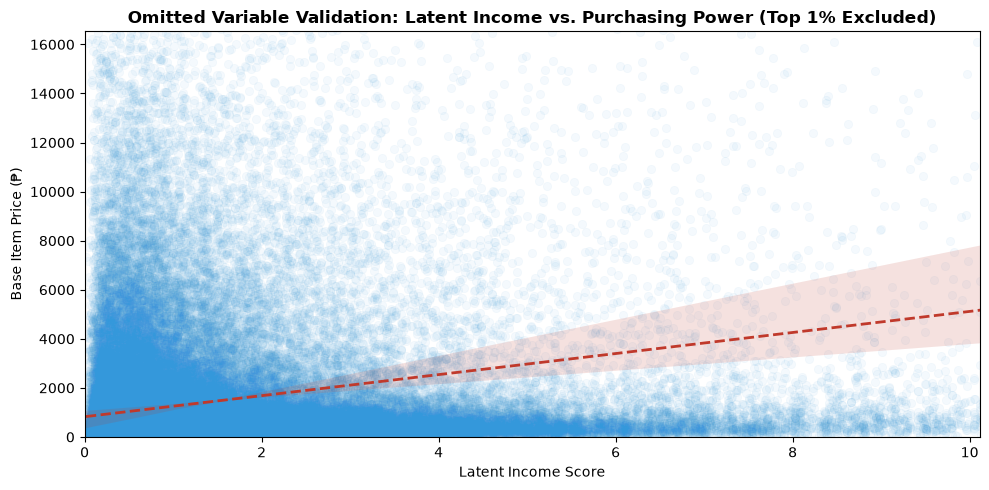

In [20]:
def internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items):
    purchase_sessions = df_events[df_events['event_name'] == 'purchase']['session_id'].unique()
    orphaned_orders = df_orders[~df_orders['session_id'].isin(purchase_sessions)]
    
    print("\nReferential Integrity:")
    if orphaned_orders.empty:
        print("PASS: All orders have a corresponding 'purchase' event.")
    else:
        print(f"FAIL: Found {len(orphaned_orders)} orders without a purchase event!")
        
    print("\nMarkov Chain Funnel Calibration:")
    event_counts = df_events['event_name'].value_counts()
    views = event_counts.get('view_item', 1)
    purchases = event_counts.get('purchase', 0)
    conversion_rate = (purchases / views) * 100
    
    print(f"Total Views: {views:,}")
    print(f"Total Purchases: {purchases:,}")
    print(f"View-to-Purchase Conversion Rate: {conversion_rate:.2f}% (Target: ~2.25%)")
    
    if 1.5 <= conversion_rate <= 3.0:
        print("PASS: Conversion rate is within realistic bounds.")
    else:
        print("WARNING: Conversion rate is drifting from target.")

    print(f"\nTemporal Decay (Digital Literacy vs. Session Duration):")
    df_sess_user = df_sessions.merge(df_users[['user_id', 'latent_digital_literacy']], on='user_id')
    
    try:
        df_sess_user['literacy_decile'] = pd.qcut(df_sess_user['latent_digital_literacy'].rank(method='first'), q=10, labels=False)
        decay_trend = df_sess_user.groupby('literacy_decile')['session_duration_seconds'].mean()

        lowest_literacy_mean = decay_trend.iloc[0]
        highest_literacy_mean = decay_trend.iloc[-1]
        
        is_decreasing = lowest_literacy_mean > highest_literacy_mean
        if is_decreasing:
            print("Higher digital literacy results in lower mean session duration.")
            print(f"Bottom 10% Literacy (Novice): Avg {lowest_literacy_mean:.2f} seconds per session")
            print(f"Top 10% Literacy (Expert): Avg {highest_literacy_mean:.2f} seconds per session")
            print(f"Difference: Experts navigate {lowest_literacy_mean - highest_literacy_mean:.2f} seconds faster.")
        else:
            print("FAIL: Session duration does not correlate correctly with digital literacy.")
            print(f"Bottom 10% Mean: {lowest_literacy_mean:.2f}s | Top 10% Mean: {highest_literacy_mean:.2f}s")
    except Exception as e:
        print(f"Could not calculate deciles. Error: {e}")
        
    print("\nFinancial Shift (Latent Income vs. Base Price):")
    df_fin = df_order_items.merge(df_orders[['order_id', 'user_id']], on='order_id')
    df_fin = df_fin.merge(df_users[['user_id', 'latent_income_score']], on='user_id')

    fig, ax = plt.subplots(figsize=(10, 5))
    y_limit = df_fin['final_item_price'].quantile(0.99)
    x_limit = df_fin['latent_income_score'].quantile(0.99)

    sns.scatterplot(
        data=df_fin, 
        x='latent_income_score', 
        y='base_item_price', 
        alpha=0.05,
        color='#3498db', 
        edgecolor=None,
        ax=ax
    )
    
    sns.regplot(
        data=df_fin, 
        x='latent_income_score', 
        y='base_item_price', 
        scatter=False, 
        color='#c0392b', 
        line_kws={"linewidth": 2, "linestyle": "--"},
        ax=ax
    )
    
    ax.set_ylim(0, y_limit)
    ax.set_xlim(0, x_limit)
    
    ax.set_title("Omitted Variable Validation: Latent Income vs. Purchasing Power (Top 1% Excluded)", fontweight='bold')
    ax.set_xlabel("Latent Income Score")
    ax.set_ylabel("Base Item Price (₱)")
    
    plt.tight_layout()
    plt.show()

internal_validation(df_users, df_sessions, df_events, df_orders, df_order_items)

In [25]:
display(df_sorted_clean_users.head(20))

,user_id,account_created_at,city,region,user_tenure_days
0,b1068cd1f1fd490697b278a39392a74d,2019-07-10 00:00:06,camarines_norte,region_v,2000
1,0ba8eb767a9b42fba8e5e156b2f79940,2019-07-10 00:00:11,pampanga,region_iii,2000
2,868bbb002d7841da819150cafbbcf423,2019-07-10 00:00:27,caloocan,ncr,2000
3,37e8f9633b534516bb56c5776dee8d2b,2019-07-10 00:00:38,batangas,region_iv-a,2000
4,ea1637fc331042e09b2fd9f211c38ace,2019-07-10 00:00:44,cebu,region_vii,2000
5,118604b0f64e4e4b93b5fc5bb540fed7,2019-07-10 00:00:44,ifugao,car,2000
6,5509e515f0244213a30f93fa135a5c47,2019-07-10 00:00:46,romblon,region_iv-b,2000
7,3f889f1e406245e4b9f9bb6e52f2a47c,2019-07-10 00:00:46,cavite,region_iv-a,2000
8,27ffa1c1e83a4daaad8b0478cd21830e,2019-07-10 00:00:57,tarlac,region_iii,2000
9,b3a0389836d34f82b19a77fac415d6fd,2019-07-10 00:01:08,capiz,region_vi,2000


In [29]:
display(df_sessions.head(20))

,session_id,user_id,session_number,acq_channel,utm_source,utm_medium,utm_campaign,session_start_time,session_end_time,session_duration_seconds,device_operating_system,device_operating_system_version,device_group
0,de989c80d1e8450ca89462a17d30f038,56a7e69b63bd4fd184c23bce6b16414b,1,organic,google,organic,(not_set),2024-03-15 19:20:48,2024-03-15 19:20:58,10,macos,ventura,desktop
1,e2fe7b2ba6c04c4399eeaf859c3510e2,f0f384b4b3734951bb1e4855f6daca11,1,tiktok,tiktok,affiliate,summer_vibes,2023-12-27 12:27:41,2023-12-27 12:31:01,200,macos,monterey,desktop
2,5b1e0c0720d444d1bf465778a8fc0664,d738a9f1d55e44bd95d1d5fc02363e22,1,meta,messenger,social,spring_sale,2024-07-05 15:25:52,2024-07-05 15:26:02,10,windows,10,desktop
3,5b91db2c54ad4d1689ef3863a8a68a07,126442666fd341ba8086e311add75048,1,tiktok,tiktok,live,summer_vibes,2024-11-23 16:50:58,2024-11-23 16:52:35,97,windows,11,desktop
4,3d31bd9c6a11401bb583eed45982dbf5,d34ad4af55914ea1a01f4cc0e96c8ae1,1,meta,facebook,social,retargeting,2022-02-24 08:30:53,2022-02-24 08:34:40,227,macos,monterey,desktop
5,8d9cbdffeeaa4466b8ea66025903f7f1,d34ad4af55914ea1a01f4cc0e96c8ae1,2,direct,(direct),(none),(not_set),2022-03-06 00:18:14,2022-03-06 00:24:42,388,macos,sonoma,desktop
6,b3f1c2f7a0dc4caab2ed95ed6cdb104b,d34ad4af55914ea1a01f4cc0e96c8ae1,3,meta,messenger,social,brand_awareness,2022-02-28 15:19:57,2022-02-28 15:20:07,10,android,13,mobile
7,ebf6158293484df69cd48f29c9cf1874,d34ad4af55914ea1a01f4cc0e96c8ae1,4,direct,(direct),(none),(not_set),2022-02-25 11:36:21,2022-02-25 11:36:31,10,android,12,mobile
8,01352cdf3c554d319c6211327d9bbb02,d34ad4af55914ea1a01f4cc0e96c8ae1,5,direct,(direct),(none),(not_set),2022-02-26 22:51:55,2022-02-26 22:53:01,66,macos,sonoma,desktop
9,fd4c2ca67a3f447cacc435040ea62f2b,d34ad4af55914ea1a01f4cc0e96c8ae1,6,meta,facebook,cpc,brand_awareness,2022-03-01 21:55:53,2022-03-01 21:56:09,16,ios,16.5,mobile


In [27]:
display(df_sorted_events.head(20))

,event_id,session_id,event_timestamp,event_name,viewed_category,android_error
0,e3e9023b-ef2b-45c2-af0d-0435cda3a549,388c587e0b6b4dcc9f497b0642c8241c,2019-07-10 00:00:02,view_item,baby_and_kids,NaN
1,c896cb59-cec9-4b25-9a78-25f7268ad91d,388c587e0b6b4dcc9f497b0642c8241c,2019-07-10 00:00:20,view_item_list,baby_and_kids,NaN
2,f33445c8-1bb6-494a-98cd-57969c098129,230e5ac0c2b14cf5a97aaa3f8284ac8b,2019-07-10 00:00:22,view_item,lifestyle_and_fitness,NaN
3,87cb13c1-529e-47a7-808d-248438685c29,230e5ac0c2b14cf5a97aaa3f8284ac8b,2019-07-10 00:00:28,add_to_cart,lifestyle_and_fitness,NaN
4,c73b34d9-91b1-4e65-8353-a4d08ef80e1f,388c587e0b6b4dcc9f497b0642c8241c,2019-07-10 00:00:32,view_item,beauty_and_personal_care,NaN
5,4faa1447-5364-4df3-b2cd-f61af3715831,388c587e0b6b4dcc9f497b0642c8241c,2019-07-10 00:00:32,select_item,baby_and_kids,NaN
6,592a3fed-22e1-475a-8e32-556e677845d9,388c587e0b6b4dcc9f497b0642c8241c,2019-07-10 00:00:39,add_to_cart,beauty_and_personal_care,NaN
7,e2a27c83-cfc0-4837-a8b9-0ab2c045c8c0,b6aebc4bbb604f2e9408e38eca5364eb,2019-07-10 00:00:52,view_item,baby_and_kids,NaN
8,f860d35f-530c-452b-a1fb-573a1b3fadaa,b6aebc4bbb604f2e9408e38eca5364eb,2019-07-10 00:00:59,add_to_cart,baby_and_kids,NaN
9,2d17573e-cb57-40c1-97a6-5a267c2fb04f,230e5ac0c2b14cf5a97aaa3f8284ac8b,2019-07-10 00:01:04,view_cart,lifestyle_and_fitness,NaN


In [28]:
display(df_sorted_orders.head(20))

,order_id,session_id,user_id,order_timestamp,payment_type
0,5542274e6029491c99dc2e2e363580c7,230e5ac0c2b14cf5a97aaa3f8284ac8b,05d65af8e3de4f6abc00da74060d80f1,2019-07-10 00:03:17,cod
1,ada8e8595ec5474ea99086540e02813e,ca262841db1d437b99cfd445cf475ea0,20710a29e0cf440ea75c0a67cac7fecd,2019-07-10 00:08:35,digital_wallet
2,cdaf0b45930e4efa92478c6042cdbdfe,83bff29b0de64fab88bec1031e796d76,b4411692df494d7db53606d8081348fe,2019-07-10 00:13:06,credit_card
3,755d4861985046d5890f95782a948403,c68d9d6691d140ec9f808530fca16984,3d1736c596de4192a3180a65429ed68c,2019-07-10 00:38:50,cash_payments
4,5e3a8e2e6b574dc3a10e8d20abe1d47e,86cbff49ed0d4dcda53c121a47c41cda,8fff8d9e380e43aaa8a835394ea5134e,2019-07-10 01:26:37,digital_wallet
5,68aa43261d13479d9ce34f3e79b412b4,9631ef31c4044565bccd56552fd7ba5e,61c4b80dd92741baadccc100ca45cd62,2019-07-10 01:48:19,bank_transfer
6,2f4c128afbc94ca0b6c0adb68197d006,06f3701beaa14f1d873a58b9c4381baa,aada00b7be46497ba2abb27224a1b45f,2019-07-10 02:35:19,cod
7,0f8b4944fe2e4b88b116274730c994c5,05970d261a5240e29762db060c144a1e,544c6755ad8f4fd9a1358ad7282dd04e,2019-07-10 03:01:10,digital_wallet
8,41f5e739754246819b2c169f497e79d7,6783d02eb2fc463e8a802b5accfba562,6c5a34cd47fd499cbee78423fdb2fd5a,2019-07-10 04:14:46,credit_card
9,5420649ffe4a491d8fe90efb56b31bc3,b2f5516c911c4f9a825d05d9557686a2,66732707f3364bd8b3d868fc712c5215,2019-07-10 04:28:45,digital_wallet


In [18]:
display(df_order_items.head(20))

,order_item_id,order_id,item_category,base_item_price,final_item_price,quantity,promo_tier_percentage,discount_amount
0,6d6f9a93a84b4116a5f5f7c85005fa5c,f8749add5fb7419496fba6fe5f525312,furniture_and_home_appliances,2321.99,2321.99,1,0.00,0.0000
1,4b14f085be0c401f80494a3b30cf69a1,06775b1dba974d1a91b780e904b8f684,fashion_and_apparel,463.99,463.99,1,0.00,0.0000
2,aabe5af9c9474d92909c1fe75ab3325c,06775b1dba974d1a91b780e904b8f684,beauty_and_personal_care,515.99,515.99,1,0.00,0.0000
3,4a03d805d1004f879c0a4c65d48f4dbf,06775b1dba974d1a91b780e904b8f684,beauty_and_personal_care,569.99,569.99,1,0.00,0.0000
4,c8bcff04ae6c4ab79286ffb9dd944fca,06775b1dba974d1a91b780e904b8f684,fashion_and_apparel,513.99,513.99,1,0.00,0.0000
5,3335d152b7484b5c8410735f5f664490,06775b1dba974d1a91b780e904b8f684,beauty_and_personal_care,226.99,226.99,1,0.00,0.0000
6,ff740844e7a64ce98c8fc654fcc4952f,f4766d6cfcfb4552b1aa840003a1513a,baby_and_kids,848.99,848.99,1,0.00,0.0000
7,a0bd38328f8a4cb9b23ad3e06e318962,f4766d6cfcfb4552b1aa840003a1513a,baby_and_kids,436.99,436.99,1,0.00,0.0000
8,997e46a05bb747a9bb5e3a23c6b0cceb,f4766d6cfcfb4552b1aa840003a1513a,beauty_and_personal_care,134.99,134.99,1,0.00,0.0000
9,981a67ac64e94d3a8188cbb50e780a1b,0f827670426e4a2ba8da9d58aa82cd9d,fashion_and_apparel,1147.99,1147.99,1,0.00,0.0000
